# Cross-Visit Generalization

**Cross-visit generalization**: Does a late-fusion model trained on visit-1 data predict visit-2 choices, vs. a model trained on visit-2 data itself (within-visit LOSO baseline)? If it does, decision signatures are stable traits. If not, strategies shifted between sessions.

**Data structure**: `user_id` in session_mapping is the desktop/hardware ID (only 3 unique values), not individual people. The real repeated unit is **team members** — a team of ~3 people returns for visit 2. All 34 visit-2 subject sessions come from the 12 teams that also had a visit-1 session. Each `subject_id` (mmdd_hhmm_userid) uniquely identifies one person's session.

In [2]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import chi2
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score
from sklearn.impute import SimpleImputer
import statsmodels.formula.api as smf

from src.utils.io import load_features

RESULTS_DIR = Path('../../data/results/main/cross_visit')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TIMEFRAME = 'PRE'
RANDOM_STATE = 42

## 1. Load Data

In [3]:
feature_data = load_features(f'../../data/features/extracted_features_{TIMEFRAME}.pkl', timeframe=TIMEFRAME)

df = feature_data['merged_df'].copy()
physio_cols = feature_data['physio_cols']
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

# Add visit info
sm = pd.read_csv('../../data/results/session_mapping.csv',
                 dtype={'mmdd': str, 'hhmm': str, 'user_id': str})
sm['subject_id'] = sm['mmdd'] + '_' + sm['hhmm'] + '_' + sm['user_id']

df = df.merge(sm[['subject_id', 'visit_number', 'team']], on='subject_id', how='left')

print(f"Total trials: {len(df)}, subjects: {df['subject_id'].nunique()}")
print("Trials per visit:")
print(df['visit_number'].value_counts().sort_index())
print(f"\nNaN visit: {df['visit_number'].isna().sum()} trials")

Total trials: 12107, subjects: 102
Trials per visit:
visit_number
1.0    5780
2.0    3870
3.0     939
Name: count, dtype: int64

NaN visit: 1518 trials


In [4]:
# Teams that appear in both visit 1 and visit 2
teams_v1 = set(sm[sm['visit_number'] == 1.0]['team'].dropna())
teams_v2 = set(sm[sm['visit_number'] == 2.0]['team'].dropna())
repeated_teams = sorted(teams_v1 & teams_v2)

print(f"Teams with visit 1 only: {len(teams_v1 - teams_v2)}")
print(f"Teams with both visit 1 and 2: {len(repeated_teams)}")
print(f"Repeated teams: {repeated_teams}")

v1 = df[df['visit_number'] == 1.0].copy()
v2 = df[df['visit_number'] == 2.0].copy()
v2_repeat = v2[v2['team'].isin(repeated_teams)].copy()

print(f"\nVisit 1: {v1['subject_id'].nunique()} subjects, {len(v1)} trials")
print(f"Visit 2 (repeated teams): {v2_repeat['subject_id'].nunique()} subjects, {len(v2_repeat)} trials")

Teams with visit 1 only: 6
Teams with both visit 1 and 2: 12
Repeated teams: ['Team 12', 'Team 15', 'Team 16', 'Team 17', 'Team 18', 'Team 20', 'Team 21', 'Team 22', 'Team 23', 'Team 24', 'Team 25', 'Team 26']

Visit 1: 48 subjects, 5780 trials
Visit 2 (repeated teams): 34 subjects, 3870 trials


## 2. Cross-Visit Generalization

**Design**:
- **Baseline**: LOSO on visit-2 data only (how well can visit-2 subjects predict each other)
- **Cross-visit**: Train on all visit-1 data, test on each visit-2 subject individually
- **Oracle**: LOSO on visit-1 data (upper-bound reference)

If cross-visit ≈ baseline, decision signatures generalize across sessions. If cross-visit < baseline, the model needs to see visit-2 data to capture within-session drift.

In [5]:
def make_features(sub_df, physio_cols, behavior_cols, gaze_cols):
    imp = SimpleImputer(strategy='mean')
    X = imp.fit_transform(sub_df[physio_cols + behavior_cols + gaze_cols])
    y = sub_df['outcome'].values
    subjects = sub_df['subject_id'].values
    return X, y, subjects


def run_loso(X, y, subjects, random_state=RANDOM_STATE):
    logo = LeaveOneGroupOut()
    all_true, all_pred, subj_accs = [], [], []
    unique_subjs = np.unique(subjects)

    for train_idx, test_idx in logo.split(X, y, subjects):
        clf = RandomForestClassifier(
            n_estimators=100, class_weight='balanced',
            random_state=random_state, n_jobs=-1
        )
        clf.fit(X[train_idx], y[train_idx])
        pred = clf.predict(X[test_idx])
        all_true.extend(y[test_idx])
        all_pred.extend(pred)
        subj_accs.append({
            'subject_id': subjects[test_idx[0]],
            'accuracy': accuracy_score(y[test_idx], pred),
            'n_trials': len(test_idx)
        })

    return {
        'accuracy': accuracy_score(all_true, all_pred),
        'f1': f1_score(all_true, all_pred, average='weighted'),
        'subject_df': pd.DataFrame(subj_accs)
    }

In [6]:
# --- Oracle: LOSO on visit 1 ---
X1, y1, s1 = make_features(v1, physio_cols, behavior_cols, gaze_cols)
print("Running LOSO on visit 1 (oracle)...")
res_v1 = run_loso(X1, y1, s1)
print(f"  Visit 1 LOSO accuracy: {res_v1['accuracy']:.4f}, F1: {res_v1['f1']:.4f}")

# --- Baseline: LOSO on visit 2 ---
X2, y2, s2 = make_features(v2_repeat, physio_cols, behavior_cols, gaze_cols)
print("Running LOSO on visit 2 (baseline)...")
res_v2 = run_loso(X2, y2, s2)
print(f"  Visit 2 LOSO accuracy: {res_v2['accuracy']:.4f}, F1: {res_v2['f1']:.4f}")

Running LOSO on visit 1 (oracle)...
  Visit 1 LOSO accuracy: 0.7346, F1: 0.7206
Running LOSO on visit 2 (baseline)...
  Visit 2 LOSO accuracy: 0.7395, F1: 0.7106


In [7]:
# --- Cross-visit: train on visit 1, test each visit-2 subject ---
print("Running cross-visit (train V1 → test V2 subjects)...")

imp_full = SimpleImputer(strategy='mean')
X1_full = imp_full.fit_transform(v1[physio_cols + behavior_cols + gaze_cols])
y1_full = v1['outcome'].values

# Train one model on ALL visit-1 data
clf_cross = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
clf_cross.fit(X1_full, y1_full)

# Test on each visit-2 subject individually
cross_subj = []
imp_v2 = SimpleImputer(strategy='mean')
X2_full = imp_v2.fit_transform(v2_repeat[physio_cols + behavior_cols + gaze_cols])

for subj in v2_repeat['subject_id'].unique():
    mask = v2_repeat['subject_id'].values == subj
    y_s = v2_repeat['outcome'].values[mask]
    X_s = X2_full[mask]
    pred_s = clf_cross.predict(X_s)
    cross_subj.append({
        'subject_id': subj,
        'team': v2_repeat[v2_repeat['subject_id'] == subj]['team'].values[0],
        'accuracy_cross': accuracy_score(y_s, pred_s),
        'n_trials': len(y_s)
    })

cross_df = pd.DataFrame(cross_subj)
cross_acc_overall = accuracy_score(
    v2_repeat['outcome'].values,
    clf_cross.predict(X2_full)
)
print(f"  Cross-visit accuracy (aggregate): {cross_acc_overall:.4f}")
print(f"  Cross-visit accuracy (mean subject): {cross_df['accuracy_cross'].mean():.4f} ± {cross_df['accuracy_cross'].std():.4f}")

Running cross-visit (train V1 → test V2 subjects)...
  Cross-visit accuracy (aggregate): 0.7612
  Cross-visit accuracy (mean subject): 0.7622 ± 0.1449


In [8]:
# Merge cross-visit and within-v2 LOSO subject accuracies for comparison
compare_df = cross_df.merge(
    res_v2['subject_df'].rename(columns={'accuracy': 'accuracy_within_v2'}),
    on='subject_id'
)

compare_df['delta'] = compare_df['accuracy_cross'] - compare_df['accuracy_within_v2']

t_stat, p_val = stats.ttest_rel(compare_df['accuracy_cross'], compare_df['accuracy_within_v2'])
print(f"Paired t-test (cross-visit vs within-v2 LOSO): t={t_stat:.3f}, p={p_val:.4f}")
print(f"Mean delta (cross - within): {compare_df['delta'].mean():.4f} ± {compare_df['delta'].std():.4f}")
print(compare_df[['subject_id', 'team', 'accuracy_cross', 'accuracy_within_v2', 'delta', 'n_trials_x']].sort_values('delta').to_string())

Paired t-test (cross-visit vs within-v2 LOSO): t=1.893, p=0.0672
Mean delta (cross - within): 0.0165 ± 0.0509
           subject_id     team  accuracy_cross  accuracy_within_v2     delta  n_trials_x
7   0825_1000_9M4VCHG  Team 17        0.555556            0.666667 -0.111111           9
5   0823_1400_U9TEJGM  Team 15        0.569106            0.626016 -0.056911         123
13  0831_1300_539136F  Team 21        0.800000            0.830769 -0.030769         130
6   0825_1000_539136F  Team 17        0.891892            0.918919 -0.027027          37
29  0930_1700_9M4VCHG  Team 25        0.714286            0.741071 -0.026786         112
19  0917_1030_539136F  Team 22        0.610687            0.633588 -0.022901         131
2   0816_1400_U9TEJGM  Team 12        0.648000            0.656000 -0.008000         125
24  0923_1000_U9TEJGM  Team 23        0.765625            0.773438 -0.007812         128
23  0923_1000_9M4VCHG  Team 23        0.931298            0.938931 -0.007634         131


In [9]:
# Also add visit-1 LOSO per-subject accuracy for the same teams
v1_team_subj = res_v1['subject_df'].copy()
v1_team_subj = v1_team_subj.merge(sm[['subject_id','team']], on='subject_id', how='left')
v1_repeated_teams_acc = v1_team_subj[v1_team_subj['team'].isin(repeated_teams)]

print("\nVisit-1 LOSO accuracy (repeated teams only):")
print(f"  Mean: {v1_repeated_teams_acc['accuracy'].mean():.4f} ± {v1_repeated_teams_acc['accuracy'].std():.4f}")
print(f"\nSummary table:")
print(f"  V1 LOSO (repeated teams): {v1_repeated_teams_acc['accuracy'].mean():.4f}")
print(f"  V2 LOSO (within-visit):   {res_v2['subject_df']['accuracy'].mean():.4f}")
print(f"  Cross-visit (V1→V2):      {cross_df['accuracy_cross'].mean():.4f}")


Visit-1 LOSO accuracy (repeated teams only):
  Mean: 0.7355 ± 0.1262

Summary table:
  V1 LOSO (repeated teams): 0.7355
  V2 LOSO (within-visit):   0.7456
  Cross-visit (V1→V2):      0.7622


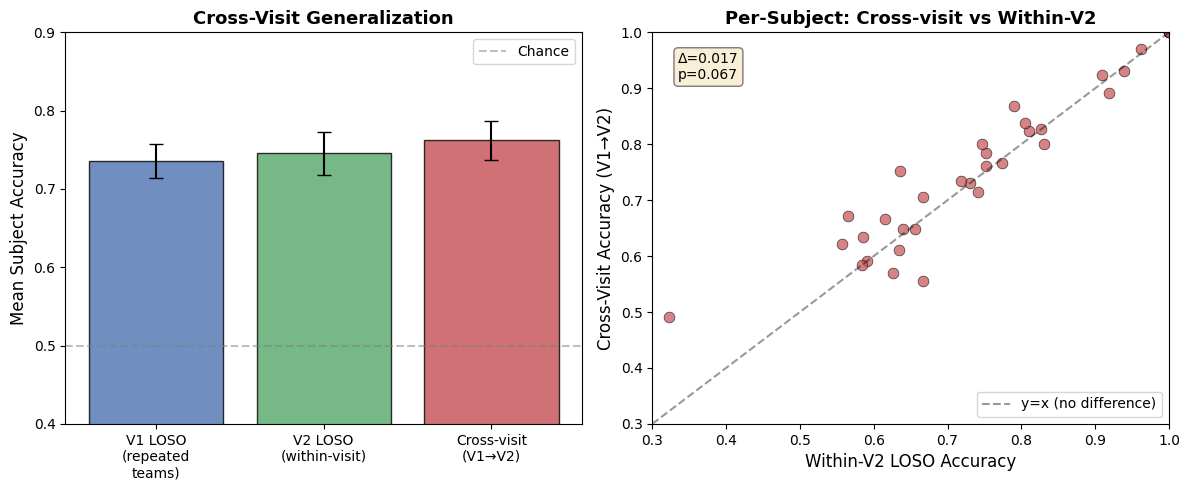

Saved figure.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: summary bar chart
ax = axes[0]
labels = ['V1 LOSO\n(repeated\nteams)', 'V2 LOSO\n(within-visit)', 'Cross-visit\n(V1→V2)']
means = [
    v1_repeated_teams_acc['accuracy'].mean(),
    res_v2['subject_df']['accuracy'].mean(),
    cross_df['accuracy_cross'].mean()
]
sems = [
    v1_repeated_teams_acc['accuracy'].sem(),
    res_v2['subject_df']['accuracy'].sem(),
    cross_df['accuracy_cross'].sem()
]
colors = ['#4C72B0', '#55A868', '#C44E52']
bars = ax.bar(labels, means, yerr=sems, capsize=5, color=colors, alpha=0.8, edgecolor='black')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax.set_ylabel('Mean Subject Accuracy', fontsize=12)
ax.set_title('Cross-Visit Generalization', fontsize=13, fontweight='bold')
ax.set_ylim(0.4, 0.9)
ax.legend()

# Panel B: subject-level scatter (cross-visit vs within-v2)
ax = axes[1]
ax.scatter(compare_df['accuracy_within_v2'], compare_df['accuracy_cross'],
           alpha=0.7, s=60, color='#C44E52', edgecolors='black', linewidth=0.5)
lims = [0.3, 1.0]
ax.plot(lims, lims, 'k--', alpha=0.4, label='y=x (no difference)')
ax.set_xlabel('Within-V2 LOSO Accuracy', fontsize=12)
ax.set_ylabel('Cross-Visit Accuracy (V1→V2)', fontsize=12)
ax.set_title('Per-Subject: Cross-visit vs Within-V2', fontsize=13, fontweight='bold')
ax.set_xlim(lims)
ax.set_ylim(lims)

# Annotate with t-test
ax.text(0.05, 0.95, f'Δ={compare_df["delta"].mean():.3f}\np={p_val:.3f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cross_visit_generalization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure.")

## 3. Summary

In [11]:
print("=" * 60)
print("CROSS-VISIT GENERALIZATION")
print("=" * 60)
print(f"  V1 LOSO (oracle, repeated teams):  {v1_repeated_teams_acc['accuracy'].mean():.4f} ± {v1_repeated_teams_acc['accuracy'].sem():.4f}")
print(f"  V2 LOSO (within-visit baseline):   {res_v2['subject_df']['accuracy'].mean():.4f} ± {res_v2['subject_df']['accuracy'].sem():.4f}")
print(f"  Cross-visit (V1→V2):               {cross_df['accuracy_cross'].mean():.4f} ± {cross_df['accuracy_cross'].sem():.4f}")
print(f"  Δ cross - within: {compare_df['delta'].mean():.4f}, t={t_stat:.3f}, p={p_val:.4f}")

# Save summary
summary = {
    'v1_loso_acc': v1_repeated_teams_acc['accuracy'].mean(),
    'v2_loso_acc': res_v2['subject_df']['accuracy'].mean(),
    'cross_visit_acc': cross_df['accuracy_cross'].mean(),
    'cross_vs_within_delta': compare_df['delta'].mean(),
    'cross_vs_within_p': p_val,
}
pd.Series(summary).to_csv(RESULTS_DIR / 'summary.csv')
print(f"\nResults saved to {RESULTS_DIR}")

CROSS-VISIT GENERALIZATION
  V1 LOSO (oracle, repeated teams):  0.7355 ± 0.0213
  V2 LOSO (within-visit baseline):   0.7456 ± 0.0273
  Cross-visit (V1→V2):               0.7622 ± 0.0249
  Δ cross - within: 0.0165, t=1.893, p=0.0672

Results saved to ../../data/results/main/cross_visit
